# 05_02 - Quantile Regression: Uncertainty-Aware Forecasting
## 1. Methodology Overview

This notebook uses the real project splits and trains the quantile regression models that feed the decision engine.
The implementation lives in `src/models/quantile_models.py`, `src/models/train_model.py`, and `src/models/evaluate_model.py`.

**Source data used in this notebook:**
- `data/processed/train_features.csv`
- `data/processed/validation_features.csv`

The goal is to estimate conditional quantiles of the next-day spot price, not to invent synthetic uncertainty.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = Path('../../').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config.constants import DATE_COLUMN, TARGET_COLUMN
from src.models.quantile_models import get_default_quantile_feature_columns

train_path = Path('../../data/processed/train_features.csv')
validation_path = Path('../../data/processed/validation_features.csv')

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)

train_df[DATE_COLUMN] = pd.to_datetime(train_df[DATE_COLUMN])
validation_df[DATE_COLUMN] = pd.to_datetime(validation_df[DATE_COLUMN])

feature_columns = get_default_quantile_feature_columns()
available_feature_columns = [column for column in feature_columns if column in train_df.columns and column in validation_df.columns]

print(f'Train features: {train_df.shape[0]} rows x {train_df.shape[1]} columns')
print(f'Validation features: {validation_df.shape[0]} rows x {validation_df.shape[1]} columns')
print(f'Default quantile features available: {len(available_feature_columns)} / {len(feature_columns)}')
print(f'Target column: {TARGET_COLUMN}')

display(train_df[[DATE_COLUMN, TARGET_COLUMN]].head())

Train features: 1461 rows x 155 columns
Validation features: 366 rows x 155 columns
Default quantile features available: 37 / 38
Target column: Spot_Price_SPEL


,date,Spot_Price_SPEL
0,2020-01-01,35.54
1,2020-01-02,40.00
2,2020-01-03,39.51
3,2020-01-04,35.67
4,2020-01-05,38.18


## 2. Training the Quantile Suite

The project uses gradient-boosted quantile regressors to estimate the central forecast and upper-tail risk.
The model wrapper is `src.models.train_model.train_quantile_suite(...)`, which reuses the feature configuration from the repository settings.

In [2]:
from src.models.train_model import train_quantile_suite

quantile_output = train_quantile_suite(train_df=train_df, eval_df=validation_df)

display(quantile_output.summary)
print(f'Used features: {len(quantile_output.used_features)}')
trained_quantiles = ', '.join(str(result.quantile) for result in quantile_output.results)
print(f'Quantiles trained: {trained_quantiles}')

,model_name,quantile,pinball_loss,mae,rmse
0,gbr_quantile_0.5,0.50,7.977632,15.955264,20.194186
1,gbr_quantile_0.9,0.90,4.857351,22.790294,28.525883
2,gbr_quantile_0.95,0.95,3.840220,26.262822,32.755788


Used features: 37
Quantiles trained: 0.5, 0.9, 0.95


## 3. Quantile Diagnostics

The evaluation layer checks empirical coverage and interval width using `src/models/evaluate_model.py`.
This is the bridge between forecasting and the decision engine because the policy reacts to both the central forecast and the upper tail.

In [3]:
from src.models.evaluate_model import combine_quantile_predictions, evaluate_prediction_interval, evaluate_quantile_coverage

prediction_frame = combine_quantile_predictions(quantile_output.results)
coverage_q50 = evaluate_quantile_coverage(prediction_frame, 'q_0.5')
coverage_q90 = evaluate_quantile_coverage(prediction_frame, 'q_0.9')
interval_q50_q90 = evaluate_prediction_interval(prediction_frame, 'q_0.5', 'q_0.9')

display(pd.DataFrame([coverage_q50, coverage_q90]))
display(interval_q50_q90)
display(prediction_frame.head())

,quantile,empirical_coverage,coverage_error,n_obs
0,0.5,0.483680,-0.016320,337.0
1,0.9,0.703264,-0.196736,337.0


,lower_quantile_column,upper_quantile_column,empirical_coverage,average_interval_width,n_obs
0,q_0.5,q_0.9,0.219585,16.815517,337.0


,y_true,q_0.5,q_0.9,q_0.95
28,81.28,80.235959,83.679672,86.187242
29,84.26,86.721442,86.721442,87.077401
30,70.95,83.379503,84.115509,87.446345
31,65.32,71.289227,77.015751,77.015751
32,60.32,61.630357,73.029693,73.029693


## 4. Temporal Logic: What the Quantile Model Actually Forecasts

A critical design choice: the quantile model does **not** predict tomorrow's known spot price.
In the OMIP Day-Ahead market, the t+1 spot price is **published at 13:00 today**, so it is
treated as a deterministic input — not a target.

Instead, the model predicts the **conditional distribution of the spot price at t+2 and beyond**,
which is the genuinely uncertain quantity at decision time.

```
t (today, 13:00)        t+1 (tomorrow)        t+2 ...
       |                       |                   |
  DECISION POINT           KNOWN price         UNCERTAIN
  (known: t+1 spot,       (OMIP auction)     <- quantile model
   futures M1-M6)
```

- `q_0.5` estimates the **median** expected cost beyond t+1.
- `q_0.9` estimates the **90th-percentile upper tail** — the stress scenario.

The difference `q_0.9 - Future_M1_Price` is the tail-risk premium used by the decision
engine to decide whether locking in the futures price is economically justified.

## 5. Why Tail Risk Matters: q50 vs q90

A point forecast (median) tells you the expected cost but hides the worst-case scenario.
Energy markets are **fat-tailed**: extreme price spikes are far more common than a Gaussian
distribution would predict.

| Signal | Interpretation | Policy response |
|---|---|---|
| Small q90 - q50 | Market calm, low dispersion | do_nothing — spot is fine |
| Large q90 - q50 | Market volatile, wide uncertainty | hedge — buy futures |
| q90 >> Future_M1 | Futures are cheap vs. expected extreme | definitely hedge |

This asymmetric view is what makes the DSS more than a naive hedge trigger.

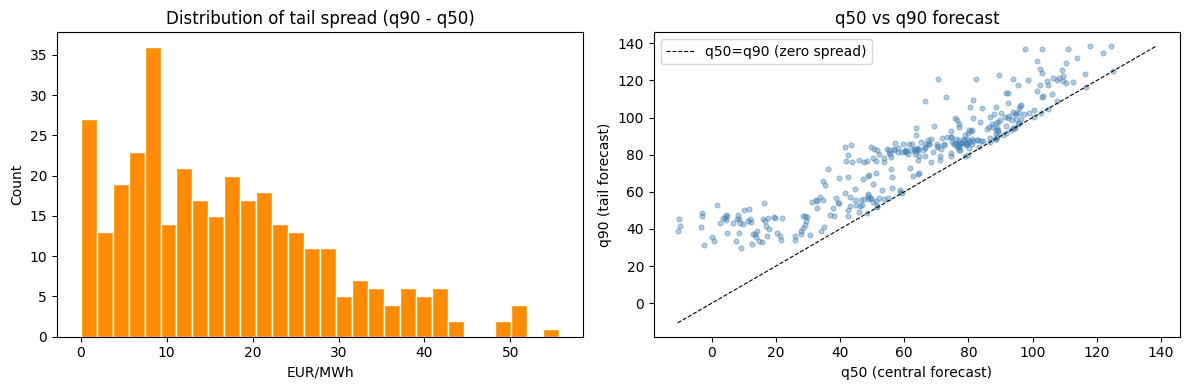

Tail spread  mean: 16.82  std: 12.04  max: 55.68


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.evaluate_model import combine_quantile_predictions
from src.models.train_model import train_quantile_suite

train_path      = project_root / 'data/processed/train_features.csv'
validation_path = project_root / 'data/processed/validation_features.csv'
train_df_q      = pd.read_csv(train_path)
validation_df_q = pd.read_csv(validation_path)

q_output   = train_quantile_suite(train_df=train_df_q, eval_df=validation_df_q)
pred_frame = combine_quantile_predictions(q_output.results)

if 'q_0.5' in pred_frame.columns and 'q_0.9' in pred_frame.columns:
    spread = pred_frame['q_0.9'] - pred_frame['q_0.5']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(spread, bins=30, color='darkorange', edgecolor='white')
    axes[0].set_title('Distribution of tail spread (q90 - q50)')
    axes[0].set_xlabel('EUR/MWh')
    axes[0].set_ylabel('Count')

    axes[1].scatter(pred_frame['q_0.5'], pred_frame['q_0.9'], alpha=0.4, s=12, color='steelblue')
    lo = min(pred_frame['q_0.5'].min(), pred_frame['q_0.9'].min())
    hi = max(pred_frame['q_0.5'].max(), pred_frame['q_0.9'].max())
    axes[1].plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='q50=q90 (zero spread)')
    axes[1].set_title('q50 vs q90 forecast')
    axes[1].set_xlabel('q50 (central forecast)')
    axes[1].set_ylabel('q90 (tail forecast)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'Tail spread  mean: {spread.mean():.2f}  std: {spread.std():.2f}  max: {spread.max():.2f}')

## 6. Sample Predictions Table

- `y_true` — realized spot price (retrospective, used only for evaluation).
- `q_0.5` and `q_0.9` — forecasts made **without** seeing `y_true`.

The validation data is strictly future relative to the training set (chronological split),
so there is no risk of data leakage.

In [5]:
show_cols = [c for c in ['y_true', 'q_0.5', 'q_0.9', 'q_0.95'] if c in pred_frame.columns]
display(pred_frame[show_cols].head(15).round(2))
display(pred_frame[show_cols].describe().round(3))

,y_true,q_0.5,q_0.9,q_0.95
28,81.28,80.24,83.68,86.19
29,84.26,86.72,86.72,87.08
30,70.95,83.38,84.12,87.45
31,65.32,71.29,77.02,77.02
32,60.32,61.63,73.03,73.03
33,63.10,53.12,60.90,67.71
34,80.92,62.85,68.79,68.79
35,74.03,64.32,77.11,77.11
36,50.11,68.31,75.89,75.89
37,38.67,56.04,62.00,62.68


,y_true,q_0.5,q_0.9,q_0.95
count,337.000,337.000,337.000,337.000
mean,62.131,61.788,78.603,83.374
std,39.825,30.922,25.867,22.887
min,0.440,-10.623,29.951,42.439
25%,28.560,42.435,55.622,60.714
50%,60.320,64.517,82.963,85.934
75%,93.590,86.354,94.502,96.689
max,146.670,125.153,138.483,138.483
